# MI

# Gépi tanulás (machine learning)
_____

## Időjárási viszonyok elemzése
Alacsony relatív páratartalmú napok előrejelzése (futótüzek elterjedésének elkerüléséhez). Felhasznált adatok: három év alatt gyűjtött időjárási adatok egy San Diego-i meteorológiai állomásról (`daily_weather.csv`). Módszer: döntési fa osztályozó modell készítése.

**1. Importálja a szükséges könyvtár(aka)t, olvassa be a `daily_weather.csv` fájlt DataFrame-ként df néven, majd írassa ki a DataFrame első 10 sorát.**

(A további részfeladatokban szükség szerint importáljon további könyvtárakat.)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('daily_weather.csv')

In [ ]:
df.head(10)

,number,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,relative_humidity_3pm
0,0,918.060000,74.822000,271.100000,2.080354,295.400000,2.863283,0.00,0.0,42.420000,36.160000
1,1,917.347688,71.403843,101.935179,2.443009,140.471548,3.533324,0.00,0.0,24.328697,19.426597
2,2,923.040000,60.638000,51.000000,17.067852,63.700000,22.100967,0.00,20.0,8.900000,14.460000
3,3,920.502751,70.138895,198.832133,4.337363,211.203341,5.190045,0.00,0.0,12.189102,12.742547
4,4,921.160000,44.294000,277.800000,1.856660,136.500000,2.863283,8.90,14730.0,92.410000,76.740000
5,5,915.300000,78.404000,182.800000,9.932014,189.000000,10.983375,0.02,170.0,35.130000,33.930000
6,6,915.598868,70.043304,177.875407,3.745587,186.606696,4.589632,0.00,0.0,10.657422,21.385657
7,7,918.070000,51.710000,242.400000,2.527742,271.600000,3.646212,0.00,0.0,80.470000,74.920000
8,8,920.080000,80.582000,40.700000,4.518619,63.000000,5.883152,0.00,0.0,29.580000,24.030000
9,9,915.010000,47.498000,163.100000,4.943637,195.900000,6.576604,0.00,0.0,88.600000,68.050000


**2. Rajzoltasson ki három különböző típusú diagramot az adatok vizualizációjához. Írja le 1-1 mondatban, hogy mi figyelhető meg az ábrákon.**

<AxesSubplot:xlabel='air_temp_9am', ylabel='Count'>

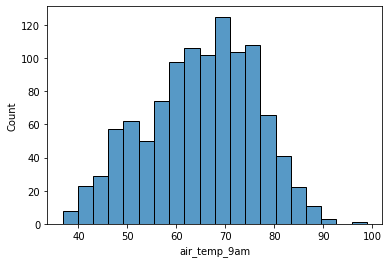

In [ ]:
sns.histplot(df['air_temp_9am'],bins=20)

Az 'air_temp_9am' hőmérséklet értékek gyakorisága. Látható, hogy legtöbbször 70 körüli értéket vett fel.

<AxesSubplot:>

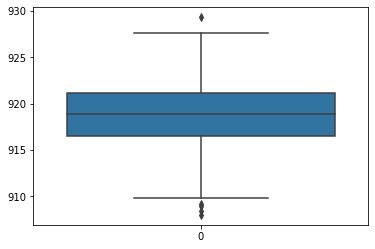

In [ ]:
sns.boxplot(data=df['air_pressure_9am'])

A légnyomás értékek dobozdiagramján látható, hogy az esetek felében az érték 917 és 922 közötti. Vannak nagyon alacsony illetve nagyon magas kiugró értékek is.

<AxesSubplot:xlabel='relative_humidity_9am', ylabel='air_temp_9am'>

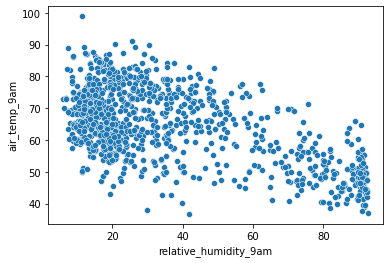

In [ ]:
sns.scatterplot(x=df['relative_humidity_9am'],y=df['air_temp_9am'])

Negatív korreláció figyelhető meg a 'relative_humidity_9am' és az 'air_temp_9am' tulajdonságok között.

**3. Távolítsa el a hiányzó értékeket tartalmazó adatsorokat az DataFrame-ből, majd írassa ki az eredményül kapott DataFrame méretét.**

In [ ]:
df2 = df.dropna()

In [ ]:
df2.shape

(1064, 11)

**4. (Plusz feladat) Készítsen egy új oszlopot `low_humidity_day` néven, amely a `relative_humidity_9am` oszlop diszkretizált értékeit tartalmazza (`if relative_humidity_9am < 25% then low_humidity_day=humidity_low, else low_humidity_day=humidity_not_low`)**

Amennyiben ezt a feladatot kihagyja, a `daily_weather2.csv` fájllal dolgozhat tovább.


In [ ]:
df3 = df2.assign(low_humidity_day = df2['relative_humidity_9am'] < 25)

In [ ]:
df3.loc[(df3['low_humidity_day'] == True),'low_humidity_day']='humidity_low'

In [ ]:
df3.loc[(df3['low_humidity_day'] == False),'low_humidity_day']='humidity_not_low'

In [ ]:
df3

,number,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,relative_humidity_3pm,low_humidity_day
0,0,918.060000,74.822000,271.100000,2.080354,295.400000,2.863283,0.0,0.0,42.420000,36.160000,humidity_not_low
1,1,917.347688,71.403843,101.935179,2.443009,140.471548,3.533324,0.0,0.0,24.328697,19.426597,humidity_low
2,2,923.040000,60.638000,51.000000,17.067852,63.700000,22.100967,0.0,20.0,8.900000,14.460000,humidity_low
3,3,920.502751,70.138895,198.832133,4.337363,211.203341,5.190045,0.0,0.0,12.189102,12.742547,humidity_low
4,4,921.160000,44.294000,277.800000,1.856660,136.500000,2.863283,8.9,14730.0,92.410000,76.740000,humidity_not_low
...,...,...,...,...,...,...,...,...,...,...,...,...
1090,1090,918.900000,63.104000,192.900000,3.869906,207.300000,5.212070,0.0,0.0,26.020000,38.180000,humidity_not_low
1091,1091,918.710000,49.568000,241.600000,1.811921,227.400000,2.371156,0.0,0.0,90.350000,73.340000,humidity_not_low
1092,1092,916.600000,71.096000,189.300000,3.064608,200.800000,3.892276,0.0,0.0,45.590000,52.310000,humidity_not_low
1093,1093,912.600000,58.406000,172.700000,3.825167,189.100000,4.764682,0.0,0.0,64.840000,58.280000,humidity_not_low


In [ ]:
# Adatok mentése a 'daily_weather2.csv' fájlba
df3.to_csv('daily_weather2.csv',index=False)

**5. Törölje a `relative_humidity_9am` és `relative_humidity_3pm` oszlopokat.**

In [ ]:
df3 = df3.drop(['relative_humidity_9am','relative_humidity_3pm'],axis=1)

In [ ]:
df3

,number,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,low_humidity_day
0,0,918.060000,74.822000,271.100000,2.080354,295.400000,2.863283,0.0,0.0,humidity_not_low
1,1,917.347688,71.403843,101.935179,2.443009,140.471548,3.533324,0.0,0.0,humidity_low
2,2,923.040000,60.638000,51.000000,17.067852,63.700000,22.100967,0.0,20.0,humidity_low
3,3,920.502751,70.138895,198.832133,4.337363,211.203341,5.190045,0.0,0.0,humidity_low
4,4,921.160000,44.294000,277.800000,1.856660,136.500000,2.863283,8.9,14730.0,humidity_not_low
...,...,...,...,...,...,...,...,...,...,...
1090,1090,918.900000,63.104000,192.900000,3.869906,207.300000,5.212070,0.0,0.0,humidity_not_low
1091,1091,918.710000,49.568000,241.600000,1.811921,227.400000,2.371156,0.0,0.0,humidity_not_low
1092,1092,916.600000,71.096000,189.300000,3.064608,200.800000,3.892276,0.0,0.0,humidity_not_low
1093,1093,912.600000,58.406000,172.700000,3.825167,189.100000,4.764682,0.0,0.0,humidity_not_low


### Döntési fa osztályozás

**6. Ossza fel az osztályozási feladatnak megfelelő adatokat tanulóhalmazra (70%) és teszthalmazra (30%) a `random_state` értékének 123-ra állítása mellett (random_state=123).**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df3.drop(['number','low_humidity_day'],axis=1), df3['low_humidity_day'], test_size=0.3, random_state=123)

**7. Ellenőrizze a kapott adathalmazok méretét.**

In [ ]:
X_train.shape

(744, 8)

In [ ]:
X_test.shape

(320, 8)

In [ ]:
y_train.shape

(744,)

In [ ]:
y_test.shape

(320,)

**8. Készítse el a döntési fa modellt és tanítsa a tanulóhalmazon. Állítsa be a modell paramétereit a következőképpen: min_samples_leaf=20, max_leaf_nodes=8, random_state=0**

In [ ]:
from sklearn import tree

In [ ]:
model = tree.DecisionTreeClassifier(min_samples_leaf=20,max_leaf_nodes=8,random_state=0)

In [ ]:
model.fit(X_train,y_train)

DecisionTreeClassifier(max_leaf_nodes=8, min_samples_leaf=20, random_state=0)

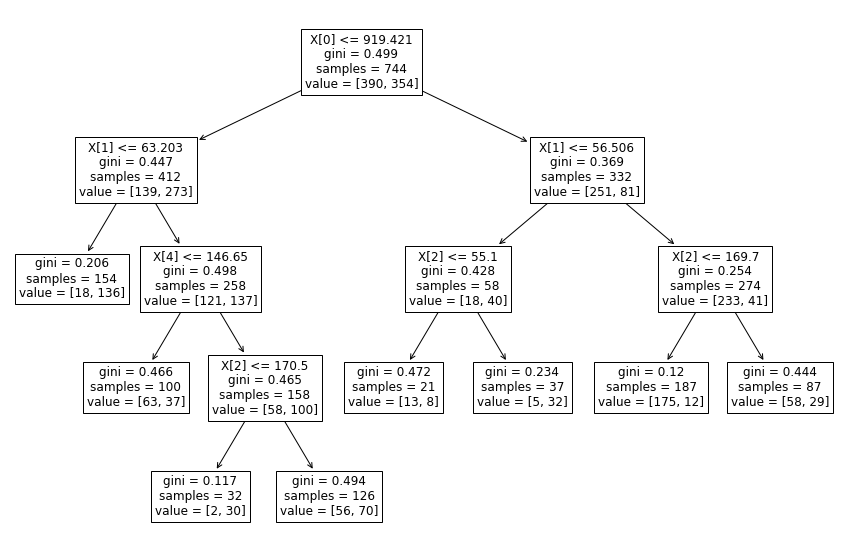

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
tree.plot_tree(model,fontsize=12);

**9. Végezze el a modell tesztelését a teszthalmazon.**

In [ ]:
predictions = model.predict(X_test)

**10. Értékelje a modellt a konfúziós mátrix és a pontosság (accuracy) meghatározásával.**

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
confusion_matrix(y_test, predictions, labels=['humidity_low','humidity_not_low'])

array([[136,  39],
       [ 30, 115]], dtype=int64)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test, predictions)

0.784375